# CSE 495/496 - LLM Agent for AV-Human Interaction

**Researchers**: Evelyn Sun & Jacqueline Louie <br>
**Advisor**: Dr. Zhichen Liu

---

## Notebook Overview

This notebook is organized in two major parts:

**Part 1 - Baseline Hawk-Dove Model (Complete Information)** <br>
We begin with a standard symmetric Hawk-Dove game between an AV and a Human. Both players know who they are facing. This was our **initial attempt**. We document it here but ultimately abandoned it — see the note in Section 1.1 for reasons. Part 2 contains the model we actually use.

**Part 2 - Bayesian Incomplete Information Model** <br>
We extend the model to introduce uncertainty — humans cannot tell whether
the other vehicle is an AV or another human. We introduce `α` as the AV
adoption rate (the probability that a given vehicle is an AV) and use it
as our key parameter. We start by establishing three complete-information
benchmarks (Human vs Human, Human vs AV, AV vs AV) to show that humans
behave differently depending on who they face. We then introduce the
Bayesian model where the Human faces an unknown opponent, and derive the
dominance gap — the mathematical proof that rushing becomes the rational
strategy the moment any AVs enter the traffic mix.

---

### Key Notation


| Symbol | Meaning |
|--------|---------|
| R | Rush (Hawk) — take the right of way aggressively |
| Y | Yield (Dove) — give up the right of way |
| v | Value of winning the right of way |
| c | Cost of collision (negative payoff) |
| w | Cost of yielding (opportunity cost) |
| γ | Yield cost parameter — higher γ means yielding is more costly |
| p | Rush probability (used throughout Parts 1 and 2) |
| p* | Mixed NE rush probability |
| q* | Opponent's mixed NE rush probability |
| α | AV adoption rate — probability a given vehicle is an AV (Part 2 only) |


---
# PART 1: Baseline Hawk-Dove Model (Complete Information)

## 1.1 Setup & Motivation

> **Research Note:** This Part 1 model was our initial approach and is kept here as documentation of our process. We ultimately **abandoned the Hawk-Dove framework**
> for two reasons:
> 1. **AV payoff problem:** In Hawk-Dove, yielding carries a cost `-(w - γ)` for the AV.
>    But AVs are *engineered* to yield safely — being cautious should be neutral or positive,
>    not a penalty. This misrepresents AV design intent.
> 2. **Survey misalignment:** Our survey finding is that humans exploit AV *predictability*.
>    The Hawk-Dove structure doesn't distinguish between an AV that yields by design vs. a
>    human who yields strategically — it can't cleanly isolate the exploitation mechanism.
>
> Part 2 introduces the Bayesian model that addresses both issues.

The classic **Hawk-Dove game** models two agents competing for a shared resource (here: the right of way at an intersection). Each agent simulatenously chooses either to **Rush (R)** - act aggressively - or **Yield (Y)** - back down.

### Why Hawk-Dove
- If both Rush -> collision. Both lose (payoff = `c`, where `c<0`).
- If one Rushes and the other Yields -> the rusher wins the resource (`v`), the yielder pays a cost (`-w`).
- If both Yield -> no one winds decisvely (payoff = 0 each).

### Adding γ (Risk Aversion)
AVs are engineered to be **risk-averse**: they would rather yield safely than risk a collision. We model this with parameter **γ**, which scales the cost of yielding for the AV. When γ is low, the AV minds yielding less — yielding costs
little, so it is more comfortable giving up the right of way.

### Payoff Matrix (AV = Row Player, Human = Column Player)

```
                    Human: Rush (R)    Human: Yield (Y)
AV: Rush (R)           (c,  c)           (v,  -w)
AV: Yield (Y)    (w - γ,  v)              (0,   0)
```

Where γ reduces the AV's cost of yielding (γ = 1 means yielding costs nothing to the AV).


In [ ]:
!pip install nashpy

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import nashpy as nash



print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1.2 Finding the Mixed Nash Equilibrium

In a mixed Nash Equilibrium (NE), each player randomizes between Rush and Yield such that the **opponent is indifferent** between the two actions.

The plot below shows the **expected payoff to the Human** as a function of `p` (the probability that the AV rushes). The intersection of two payoff lines is `p*` - the AV's equilibrium mixing probability that makes the Human indifferent.

- If the AV rushes more than `p*`, the Human prefers to yield.
- If the AV rushes less than `p*`, the Human prefers to rush.
- At exactly `p*`, the Human is indifferent and will mix.

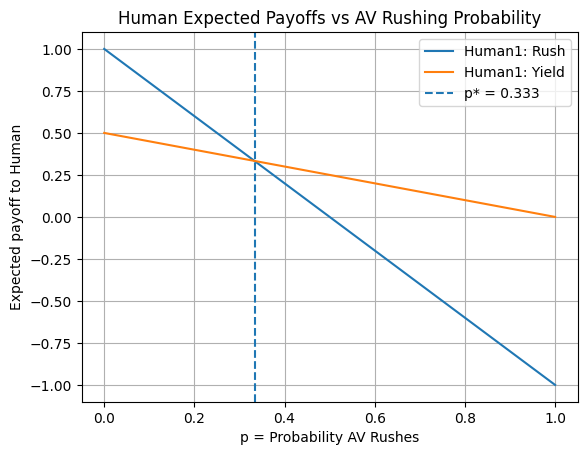

In [ ]:
# ── Finding p*: AV rush probability that makes the Human indifferent ─────────

# Fixed baseline values
v = 1.0
c = -1.0
w = 0.0

p = np.linspace(0, 1, 400)

# ---- Expected payoffs for Human ----
HUMAN_R = p*(c) + (1 - p)*v
HUMAN_Y = p*w + (1 - p)*0.5*v

# ---- Solve analytically for intersection ----
p_star = (0.5 * v) / (w + (0.5* v) - c)

# ---- Plot ----
plt.figure()
plt.plot(p, HUMAN_R, label="Human1: Rush")
plt.plot(p, HUMAN_Y, label="Human1: Yield")

# Mark equilibrium
plt.axvline(p_star, linestyle="--", label=f"p* = {p_star:.3f}")

plt.xlabel("p = Probability AV Rushes")
plt.ylabel("Expected payoff to Human")
plt.title("Human Expected Payoffs vs AV Rushing Probability")
plt.legend()
plt.grid(True)
plt.show()

## 1.3 How γ Affects the Mixed NE

Here we sweep γ (AV yield cost) from 0 to 1 and compute the full mixed NE using the `nashpy` library.

### Payoff Matrix with γ (AV = Row, Human = Column)

```
                        Human: R          Human: Y
AV: Rush (R)         (c,       c)        (v,    -w)
AV: Yield (Y)    (w - γ,       v)        (0,     0)
```

- `p*` = AV's NE rush probability (makes **Human** indifferent)
- `q*` = Human's NE rush probability (makes **AV** indifferent)

**Key insight:** `p*` depends on Human payoffs (doesn't change with γ), while `q*` depends on AV payoffs (changes with γ). As γ increases, the AV yields more comfortably -> the Human needs to rush *less* to keep the AV indifferent.

In [ ]:
# ── Payoff matrix constructor ─────────────────────────────────────────────────
def payoff_matrix(v, c, w, gamma):
    """
    Builds (A, H) payoff matrices for nashpy.
    Rows = AV actions [Rush, Yield]
    Cols = Human actions [Rush, Yield]

    gamma scales the AV's cost of yielding:
    higher gamma = AV's yield cost increases = less willing to yield
    """
    A = np.array([
        [c,          v       ],   # AV Rushes: collision / AV wins
        [w - gamma,  0.5 * v ]    # AV Yields: AV pays reduced cost / both split
    ])
    H = np.array([
        [c,   w       ],          # Human vs Rush: collision / Human yields
        [v,   0.5 * v ]           # Human vs Yield: Human wins / both split
    ])
    return A, H


def make_game(v, c, w, gamma):
    """Wraps payoff matrices into a nashpy Game object."""
    A, H = payoff_matrix(v, c, w, gamma)
    return nash.Game(A, H)


def get_mixed_ne(v, c, w, gamma):
    """
    Returns the mixed Nash Equilibrium:
      p_star: AV's Rush probability
      q_star: Human's Rush probability
      u_av:   AV's expected payoff at NE
      u_h:    Human's expected payoff at NE
    Returns (None, None, None, None) if no interior mixed NE exists.
    """
    game = make_game(v, c, w, gamma)
    for sigma_av, sigma_h in game.support_enumeration():
        # Check that both players are genuinely mixing (not a pure strategy)
        if ((sigma_av > 0).all() and (sigma_av < 1).all() and
                (sigma_h > 0).all() and (sigma_h < 1).all()):
            u_av, u_h = game[sigma_av, sigma_h]
            return float(sigma_av[0]), float(sigma_h[0]), float(u_av), float(u_h)
    return None, None, None, None

print("Functions defined.")

Functions defined.


/usr/local/lib/python3.12/dist-packages/nashpy/algorithms/support_enumeration.py:260: RuntimeWarning: 
An even number of (2) equilibria was returned. This
indicates that the game is degenerate. Consider using another algorithm
to investigate.
                  
  warnings.warn(warning, RuntimeWarning)


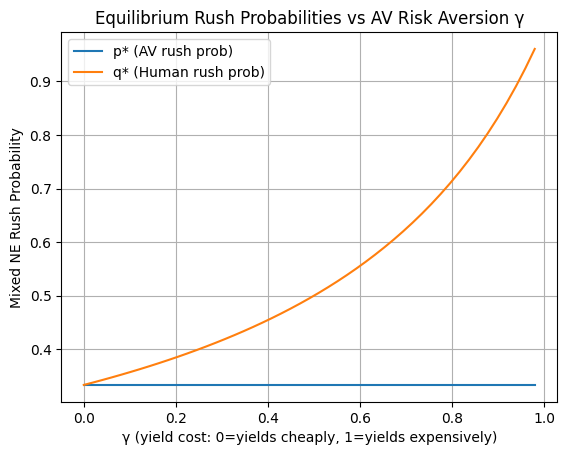

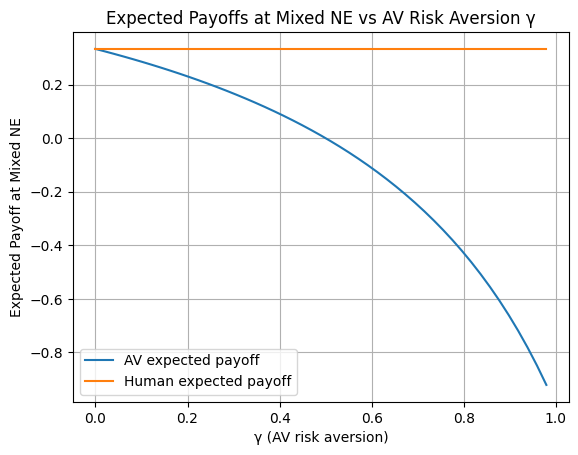

In [ ]:
# ── Sensitivity: Mixed NE vs γ ────────────────────────────────────────────────
v, c, w = 1.0, -1.0, 0.0
gammas = np.linspace(0, 1, 50)

p_list, q_list, u_av_list, u_h_list = [], [], [], []

for g in gammas:
    p_star, q_star, u_av, u_h = get_mixed_ne(v, c, w, g)
    p_list.append(p_star if p_star is not None else np.nan)
    q_list.append(q_star if q_star is not None else np.nan)
    u_av_list.append(u_av if u_av is not None else np.nan)
    u_h_list.append(u_h if u_h is not None else np.nan)

# Plot 1: Equilibrium Rush Probabilities vs γ
plt.figure()
plt.plot(gammas, p_list, label="p* (AV rush prob)")
plt.plot(gammas, q_list, label="q* (Human rush prob)")
plt.xlabel("γ (yield cost: 0=yields cheaply, 1=yields expensively)")
plt.ylabel("Mixed NE Rush Probability")
plt.title("Equilibrium Rush Probabilities vs AV Yield Cost γ")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Expected Payoffs vs γ
plt.figure()
plt.plot(gammas, u_av_list, label="AV expected payoff")
plt.plot(gammas, u_h_list, label="Human expected payoff")
plt.xlabel("γ (AV risk aversion)")
plt.ylabel("Expected Payoff at Mixed NE")
plt.title("Expected Payoffs at Mixed NE vs AV Yield Cost γ")
plt.legend()
plt.grid(True)
plt.show()

**Interpretation:**
- As γ decreases (AV's yield cost drops, making it more willing
to yield), q* (Human's rush probability) increases — the Human
rushes more because the AV is easier to exploit.
- `p*` (AV's rush probability) stays roughly constant because γ does not change the Human's payoffs.
- The AV's payoff worsens as γ increases - it becomes easier to exploit.

**Additional limitation:** The payoff structure also incorrectly penalizes the AV for yielding via the `(w - γ)` term. In reality, AV compliance with traffic law is a design feature, not a loss — this model therefore understates the AV's advantage of predictability and overstates the cost of safe behavior. This is one of the key reasons we move to a different model in Part 2.

---
# PART 2: Bayesian Incomplete Information Model

## 2.1 Why Incomplete Information?

The baseline model (Part 1) shows that AV risk aversion changes equilibrium strategies - but it assumes **each player knows who they are facing**. In reality:

- Surveys show ~60% of people **would intentionally exploit** AVs if they could identify them.
- But often humans **cannot reliably identify** whether the vehicle is an AV or not.
- AVs are equipped with V2V (Vehicle-to-Vehicle) technology **can identify each other**.

This asymmetry of information is a classic setting for a **Bayesian Game**.

## 2.2 Bayesian Game Structure

Following Levin (2002), a game with incomplete information is defined as:

$$G = (\Theta, S, P, u)$$

| Component | Our Game |
|-----------|----------|
| $\Theta = \Theta_1 \times \Theta_2$ | Types for each vehicle: {AV, Human} |
| $S = S_1 \times S_2$ | Actions for each vehicle: {Rush (R), Yield (Y)} |
| $P(\theta_1, \theta_2)$ | Joint prior: each vehicle is AV with prob $\alpha$, Human with prob $(1-\alpha)$ |
| $u_i: S \times \Theta \to \mathbb{R}$ | Payoff functions depending on actions and types |

> **Source:** Levin, J. (2002). *Games of Incomplete Information*. Stanford University,
> Econ 203 Lecture Notes. https://web.stanford.edu/~jdlevin/Econ%20203/Bayesian.pdf

## 2.3 Information Structure

**Stage 0:** Nature draws each player's type independently:
- Player 1 is AV with probability $\alpha$, Human with probability $(1-\alpha)$
- Player 2 is AV with probability $\alpha$, Human with probability $(1-\alpha)$

**Stage 1:** Each player learns their own type.
- **AV players:** Can identify each other via V2V technology → know opponent's type when facing another AV.
- **Human players:** Cannot identify opponent's type → must act under uncertainty.

**Stage 2:** Players choose actions simultaneously. Payoffs are realized.

## 2.4 Three Benchmark Scenarios

We will compare three pure cases to **show that humans behave differently depending on who they face**:

1. **Human vs Human** - Complete info, symmetric game.
2. **Human vs AV (complete info)** - Human *knows* they face an AV. Upper bound on exploitation.
3. **AV vs AV** - Both are AVs, both know it (V2V). Should be most cooperative.

Then, the Bayesian game shows what happens when the Human faces **uncertainty** (doesn't know if opponent is AV or Human).


## 2.5 Payoff Matrices and Equilibrium

The payoff structure depends on the type combination at each encounter.

**Human vs Human** (both use γ_H):
```
                    Human2: Rush      Human2: Yield
Human1: Rush      (-C,  -C)        (V,  -γ_H·W)
Human1: Yield  (-γ_H·W,  V)         (0,      0)
```

**Human vs AV** (Human uses γ_H, AV uses γ_AV):
```
                    AV: Rush        AV: Yield
Human: Rush       (-C,  -C)        (V, -γ_AV·W)
Human: Yield  (-γ_H·W,   V)         (0,      0)
```

**AV vs AV** (both use γ_AV):
```
                    AV2: Rush       AV2: Yield
AV1: Rush         (-C,  -C)        (V, -γ_AV·W)
AV1: Yield  (-γ_AV·W,   V)          (0,      0)
```

The matrices look the same structurally — the **only difference is γ**. But that difference changes the equilibrium type entirely:

- In **H vs H**: both players are symmetric and uncertain about each other → **mixed NE** emerges naturally. Both randomize at q*.
- In **H vs AV**: the AV so strongly prefers yielding (-0.2) over colliding (-10) that it will always yield to a rusher. The Human knows this → **pure NE** (Human always rushes).
- In **AV vs AV**: both are risk-averse and cooperative → **mixed NE** at a lower rush rate than H vs H.

In [ ]:
# ── Part 2 Parameters ─────────────────────────────────────────────────────────
V        = 3.0    # Value of winning right of way
C        = 10.0   # Cost of collision
W        = 1.0    # Cost of yielding
GAMMA_AV = 0.2    # AV risk aversion
GAMMA_H  = 1.0    # Human risk aversion

print(f"Parameters: V={V}, C={C}, W={W}, gamma_AV={GAMMA_AV}, gamma_H={GAMMA_H}")

Parameters: V=3.0, C=10.0, W=1.0, gamma_AV=0.2, gamma_H=1.0


## 2.6 Benchmark: Three Complete-Information Scenarios

For each scenario we identify whether the equilibrium is **mixed** (both randomize) or **pure** (one always rushes, one always yields), and compute the Human's rush probability.

**Mixed NE formula** — derived from the indifference condition (setting EU(Rush) = EU(Yield) for the opponent and solving for p):

$$p^* = \frac{V}{C + V - \gamma_{\text{opp}} \cdot W}$$

This is the rush probability that makes the **opponent** indifferent. It depends only on the opponent's γ — a more risk-averse opponent (higher γ) is indifferent at a lower p*.

In [ ]:
def mixed_ne_rush_prob(gamma_opponent, V=V, C=C, W=W):
    """
    Mixed NE rush probability — makes the OPPONENT indifferent.
    Derived from: EU(Rush) = EU(Yield) for opponent.
    p* = V / (C + V - gamma_opp * W)
    """
    return float(np.clip(V / (C + V - gamma_opponent * W), 0, 1))


def mixed_ne_payoff(p_row, p_col, gamma_row, gamma_col, V=V, C=C, W=W):
    """
    Expected payoffs at given strategies (p_row, p_col).
    Uses asymmetric payoff matrix where each player has their own gamma.
    """
    # Player 1's Payoff Matrix. (Rows = Player 1's action, Columns = Player 2's action)
    M_row = np.array([[-C,  V], [-gamma_row * W, 0]])
    # Player 2's Payoff Matrix. (Same structure but flipped because Player 2's yield cost uses their own gamma)
    M_col = np.array([[-C, -gamma_col * W], [V, 0]])

    # Player 1's mixed stategy vector
    s_row = np.array([p_row, 1 - p_row])
    # Player 2's mixed stategy vector
    s_col = np.array([p_col, 1 - p_col])

    # Matrix multiplication to compute expected payoffs
    return float(s_row @ M_row @ s_col), float(s_row @ M_col @ s_col)


print("=" * 65)
print("  BENCHMARK: Three Complete-Information Scenarios")
print(f"  V={V}, C={C}, W={W}, gamma_H={GAMMA_H}, gamma_AV={GAMMA_AV}")
print("=" * 65)

# ── 1. Human vs Human — Mixed NE ─────────────────────────────────────────────
# Both players are symmetric → each randomizes to make the other indifferent
q_hh = mixed_ne_rush_prob(gamma_opponent=GAMMA_H)   # = V / (C + V - gamma_H * W)
eu_h1_hh, eu_h2_hh = mixed_ne_payoff(q_hh, q_hh, GAMMA_H, GAMMA_H)
print(f"\n  1. Human vs Human — MIXED NE")
print(f"     Rush probability q* = {q_hh:.4f}")
print(f"     EU (each player)    = {eu_h1_hh:.4f}")
print(f"     Interpretation: Both humans randomize — neither has a dominant strategy.")

# ── 2. Human vs AV — Pure NE ─────────────────────────────────────────────────
# AV strongly prefers Yield → Human best response is to always Rush
# Verify: AV prefers Yield when Human rushes
eu_av_yield_vs_rush = -GAMMA_AV * W   # AV yields while Human rushes
eu_av_rush_vs_rush  = -C              # AV rushes while Human rushes (collision)
print(f"\n  2. Human vs AV — PURE NE: (Human Rush, AV Yield)")
print(f"     AV: Yield({eu_av_yield_vs_rush:.2f}) > Rush({eu_av_rush_vs_rush:.1f}) when facing rushed")
print(f"     Human: Rush(V={V}) > Yield(0) when AV yields")
print(f"     Human rush rate = 1.0 (always rushes)")
print(f"     Human payoff    = {V}")
print(f"     AV payoff       = {eu_av_yield_vs_rush}")
print(f"     Interpretation: Human always rushes. AV always yields. Stable pure NE.")

# ── 3. AV vs AV — Mixed NE ───────────────────────────────────────────────────
# Both AVs are symmetric and risk-averse → mixed NE at a lower rate than H vs H
q_aa = mixed_ne_rush_prob(gamma_opponent=GAMMA_AV)
eu_av1_aa, eu_av2_aa = mixed_ne_payoff(q_aa, q_aa, GAMMA_AV, GAMMA_AV)
print(f"\n  3. AV vs AV — MIXED NE")
print(f"     Rush probability q* = {q_aa:.4f}")
print(f"     EU (each AV)        = {eu_av1_aa:.4f}")
print(f"     Interpretation: Both AVs randomize but at a LOWER rate than H vs H.")

print("\n" + "-" * 65)
print("  HUMAN RUSH RATE COMPARISON:")
print(f"    H vs H  (mixed NE) : {q_hh:.4f}")
print(f"    H vs AV (pure NE)  : 1.0000")
print(f"    AV vs AV (mixed NE): {q_aa:.4f}")
print(f"\n  → Human rushes at 1.0 vs AV vs {q_hh:.4f} vs Human.")
print(f"    This supports our survey findings.")

  BENCHMARK: Three Complete-Information Scenarios
  V=3.0, C=10.0, W=1.0, gamma_H=1.0, gamma_AV=0.2

  1. Human vs Human — MIXED NE
     Rush probability q* = 0.2500
     EU (each player)    = -0.2500
     Interpretation: Both humans randomize — neither has a dominant strategy.

  2. Human vs AV — PURE NE: (Human Rush, AV Yield)
     AV: Yield(-0.20) > Rush(-10.0) when facing rushe
     Human: Rush(V=3.0) > Yield(0) when AV yields
     Human rush rate = 1.0 (always rushes)
     Human payoff    = 3.0
     AV payoff       = -0.2
     Interpretation: Human always rushes. AV always yields. Stable pure NE.

  3. AV vs AV — MIXED NE
     Rush probability q* = 0.2344
     EU (each AV)        = -0.0469
     Interpretation: Both AVs randomize but at a LOWER rate than H vs H.

-----------------------------------------------------------------
  HUMAN RUSH RATE COMPARISON:
    H vs H  (mixed NE) : 0.2500
    H vs AV (pure NE)  : 1.0000
    AV vs AV (mixed NE): 0.2344

  → Human rushes at 1.0 vs AV

## 2.7 Bayesian Nash Equilibrium — Core Model

We now model the scenario where the Human faces an unknown opponent —
AV with probability α, Human with probability (1−α).

### Human's Expected Payoffs Under Uncertainty

Since the Human cannot identify the opponent, their expected payoff
from each action is a weighted average across both opponent types:

**If Human Rushes:**
- With prob α, opponent is AV → AV yields → Human gets V
- With prob (1−α), opponent is Human → Human plays mixed NE q* → Human gets q*·(−C) + (1−q*)·V

$$EU_H(\text{Rush}) = \alpha \cdot V + (1-\alpha) \cdot [q^* \cdot (-C) + (1-q^*) \cdot V]$$

**If Human Yields:**
- With prob α, opponent is AV → AV rushes against yielder → Human gets −γ_H·W
- With prob (1−α), opponent is Human → Human plays mixed NE q* → Human gets q*·V + (1−q*)·0

$$EU_H(\text{Yield}) = \alpha \cdot (-\gamma_H \cdot W) + (1-\alpha) \cdot [q^* \cdot (-\gamma_H \cdot W) + (1-q^*) \cdot 0]$$

### Finding: Rush Dominance Grows Linearly with α

At α = 0, the two expected payoffs are equal — consistent with
the H vs H mixed NE where the Human is indifferent.

For any α > 0, EU_H(Rush) > EU_H(Yield). Taking the difference:

$$EU_H(\text{Rush}) - EU_H(\text{Yield}) = \alpha \cdot (V + \gamma_H \cdot W)$$

With our parameters: dominance gap = **4α**

This gives us a clean, testable result: the Human's incentive
to always rush increases linearly with AV adoption rate α.
At α = 0 the Human randomizes (25% rush rate). At any α > 0
the Human always rushes. The equilibrium type shifts entirely
based on fleet composition — not on how aggressive individual
drivers are, but on how many AVs are on the road.

In [ ]:
# ── Bayesian Nash Equilibrium ─────────────────────────────────────────────────

def compute_bayesian_payoffs(alpha, gamma_av=GAMMA_AV, gamma_h=GAMMA_H,
                              V=V, C=C, W=W):
    """
    Human's expected payoffs in the Bayesian game.

    Opponent is AV with prob alpha, Human with prob (1-alpha).
    Human opponent plays the H-vs-H mixed NE strategy q*.
    AV follows its best response (yields to rushers, rushes to yielders).

    EU_H(Rush)  = alpha * V + (1-alpha) * [q* * (-C) + (1-q*) * V]
    EU_H(Yield) = alpha * (-gamma_h * W) + (1-alpha) * [q* * (-gamma_h * W)]

    Dominance gap = EU_H(Rush) - EU_H(Yield) = alpha * (V + gamma_h * W)
    """
    # H vs H mixed NE rush probability
    q_hh = mixed_ne_rush_prob(gamma_opponent=gamma_h)

    # EU from Rush
    eu_vs_av = V # AV yields to rusher
    eu_vs_human = q_hh * (-C) + (1 - q_hh) * V # Human plays mixed NE
    eu_rush = alpha * eu_vs_av + (1 - alpha) * eu_vs_human

    # EU from Yield
    eu_yield_vs_av = -gamma_h * W # AV rushes against yielder
    eu_yield_vs_human = q_hh * (-gamma_h * W) + (1 - q_hh) * 0 # Human plays mixed NE
    eu_yield = alpha * eu_yield_vs_av + (1 - alpha) * eu_yield_vs_human

    # Dominance gap (positive = Rush is better)
    dominance_gap = eu_rush - eu_yield
    # Analytical formula: alpha * (V + gamma_h * W)
    dominance_gap_analytical = alpha * (V + gamma_h * W)

    return {
        'eu_rush'                  : eu_rush,
        'eu_yield'                 : eu_yield,
        'dominance_gap'            : dominance_gap,
        'dominance_gap_analytical' : dominance_gap_analytical,
        'q_hh'                     : q_hh,
    }


# ── Verify at key alpha values ────────────────────────────────────────────────
print("=" * 65)
print("  BAYESIAN NE — Human Expected Payoffs Under Uncertainty")
print("=" * 65)
print(f"  {'alpha':>6} | {'EU(Rush)':>10} | {'EU(Yield)':>10} | {'Gap':>8} | {'Rush dominant?'}")
print("  " + "-" * 60)

for a in [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]:
    res = compute_bayesian_payoffs(a)
    dominant = "YES" if res['dominance_gap'] > 1e-9 else "— indifferent (mixed NE)"
    print(f"  {a:>6.2f} | {res['eu_rush']:>10.4f} | {res['eu_yield']:>10.4f} | "
          f"{res['dominance_gap']:>8.4f} | {dominant}")

print(f"\n  At alpha=0: Human is indifferent (H vs H mixed NE, gap = 0)")
print(f"  For any alpha > 0: Rush strictly dominates")
print(f"  Dominance gap = alpha * (V + gamma_H * W) = alpha * {V + GAMMA_H * W}")

  BAYESIAN NE — Human Expected Payoffs Under Uncertainty
   alpha |   EU(Rush) |  EU(Yield) |      Gap | Rush dominant?
  ------------------------------------------------------------
    0.00 |    -0.2500 |    -0.2500 |   0.0000 | — indifferent (mixed NE)
    0.10 |     0.0750 |    -0.3250 |   0.4000 | YES
    0.25 |     0.5625 |    -0.4375 |   1.0000 | YES
    0.50 |     1.3750 |    -0.6250 |   2.0000 | YES
    0.75 |     2.1875 |    -0.8125 |   3.0000 | YES
    1.00 |     3.0000 |    -1.0000 |   4.0000 | YES

  At alpha=0: Human is indifferent (H vs H mixed NE, gap = 0)
  For any alpha > 0: Rush strictly dominates
  Dominance gap = alpha * (V + gamma_H * W) = alpha * 4.0


## Repeated Game

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42);

Parameter Definitions

v = payoff from winning

c = collision cost

w = lost of yielding when opponent rushes

q* = human opponent's mixed strategy probability

$\alpha$ = AV adoption/penetration rate -- essentially the probability that in a particular area, that the human's opponenent is AV

$\bar{\mu}$ = AV's true yield probability (assumption)

t = rounds per simulation

n_sim = number of simulated humans per scenario


In [ ]:
## Defining variable values here
v = 5
c = 10
w = 3
q_star = 0.25
alpha = 0.90
mu_bar = 0.95
t = 50
N_SIM = 1000

In [ ]:
def av_action(p_bar):
  # Draw the historical action for this round
  # True = Yielded
  # False = Rushed
  # It is calculated by comparing a uniform draw against p_bar
    return np.random.random() < p_bar

In [ ]:
def update_belief(a, b, av_yielded) :
  # Update via Beta conjugate
  # If AV yielded -> increment of a (more evidence of yielding AV)
  # If AV rushed -> increment of b (more evidence of rushing AV)
  if av_yielded:
      return a + 1, b
  else:
    return a, b + 1

In [ ]:
def EU_rush(mu, alpha, v, c, q_star):
  # EU_t(RUSH) = alpha * [mu * v + (1-mu) * -c] + (1-alpha)[q*(-c) + (1-q*)*v]
  # mu only affects the AV branch
  av_branch = mu * v + (1 - mu) * (-c)
  human_branch = q_star * (-c) + (1 - q_star) * v
  return alpha * av_branch + (1 - alpha) * human_branch

In [ ]:
def EU_yield(alpha, w, q_star):
  # EU_t(YIELD) = no mu dependency just yet, constant every round
  return alpha * (-w) + (1 - alpha) * (q_star * (-w))

In [ ]:
def dominance_gap(mu, alpha, v, c, w, q_star):
  return EU_rush(mu, alpha, v, c, q_star) - EU_yield(alpha, w, q_star)

In [ ]:
def static_gap(alpha, v, c, w, q_star):
  return dominance_gap(1.0, alpha, v, c, w, q_star)

In [ ]:
# Single simulation (one human with t rounds)
def simulate_one_human(a0, b0, mu_bar, t):
  '''
  Each round consists of:
    1. Compute current belief mu = a / (a+b)
    2. Draw AV action (yield or rush) from mu_bar
    3. Update a or b via belief update rule
    4. Record mu, EU_t(Rush), Delta(t) and whether human rushed
  Returns arrays of length T+1 (round 0 is the prior belief before any game)
  '''

  a, b = a0, b0
  mus, eus, deltas, actions = [], [], [], []

  for time_index in range(t+1):
    mu = a / (a + b)
    eu = EU_rush(mu, alpha, v, c, q_star)
    dg = dominance_gap(mu, alpha, v, c, w, q_star)

    mus.append(mu)
    eus.append(eu)
    deltas.append(dg)

    # Human rational decision: rush if gap > 0
    rushed = dg > 0
    actions.append(rushed)

    # Only update belief if there is a next round
    if time_index < t:
      # AV action is only observed if human rushed (for now)
      # (if human yields, they don't learn about AV behavior)
      if rushed:
        av_yielded = av_action(mu_bar);
        a, b = update_belief(a, b, av_yielded)
      # if human yielded, no change to a and b
  return np.array(mus), np.array(eus), np.array(deltas), np.array(actions)

In [ ]:
# Monte Carlo (simulating many humans per scenario)

def simulate_population(a0, b0, mu_bar, t, N_SIM):

  all_mus = np.zeros((N_SIM, t + 1))
  all_eus = np.zeros((N_SIM, t + 1))
  all_deltas = np.zeros((N_SIM, t + 1))
  all_actions = np.zeros((N_SIM, t + 1))

  for i in range(N_SIM):
    mus, eus, deltas, actions = simulate_one_human(a0, b0, mu_bar, t)
    all_mus[i] = mus
    all_eus[i] = eus
    all_deltas[i] = deltas
    all_actions[i] = actions
  return {
      "mus_mean": all_mus.mean(axis=0),
      "mus_std": all_mus.std(axis=0),
      "eus_mean": all_eus.mean(axis=0),
      "deltas_mean": all_deltas.mean(axis=0),
      "rush_rate": all_actions.mean(axis=0)
  }

#### Simulation with varied mu_t

In [ ]:
# (a0, b0, label) = mu_0 (prior belief) = a0 / (a0 + b0)
scenarios = [
    (1, 9, "mu_0 = 0.10"),
    (3, 7, "mu_0 = 0.30"),
    (5, 5, "mu_0 = 0.50"),
    (7, 3, "mu_0 = 0.70"),
    (9, 1, "mu_0 = 0.90"),
]
## Magenta, Purple, Blue, Green, Yellow
colors = ["#7D1D3F", "#7B6A8A", "#5F92BF", "#43AA8B", "#EEFC57"]
print(t)
rounds = np.arange(0, t + 1)
static = static_gap(alpha, v, c, w, q_star)

results = []
for (a0, b0, label) in scenarios:
  res = simulate_population(a0, b0, mu_bar, t, N_SIM)
  results.append(res)

50


In [ ]:
print("-" * 72)
print("REPEATED GAME — SIMULATION RESULTS  (N={}, p_bar={})".format(N_SIM, mu_bar))
print("Parameters: V={}, C={}, HW={}, q*={}, alpha={}".format(
    v, c, w, q_star, alpha))
print("Static BNE gap (mu=1): {:.4f}".format(static))
print("-" * 72)

for i, (a0, b0, label) in enumerate(scenarios):
  print("\n--- {} ---".format(label))
  print("{:<8} {:<12} {:<14} {:<12}".format("Round", "mu_mean", "EU_t(Rush)", "Delta_t", "Rush rate"))
  print("-" * 62)
  for t in [0, 1, 2, 5, 10, 20, 30, 40, 50]:
    print("{:<8} {:<12.4f} {:<14.4f} {:<14.4f} {:<12.2%}".format(
            t,
            results[i]["mus_mean"][t],
            results[i]["eus_mean"][t],
            results[i]["deltas_mean"][t],
            results[i]["rush_rate"][t],
        ))


------------------------------------------------------------------------
REPEATED GAME — SIMULATION RESULTS  (N=1000, p_bar=0.95)
Parameters: V=5, C=10, HW=3, q*=0.25, alpha=0.9
Static BNE gap (mu=1): 7.4000
------------------------------------------------------------------------

--- mu_0 = 0.10 ---
Round    mu_mean      EU_t(Rush)     Delta_t     
--------------------------------------------------------------
0        0.1000       -7.5250        -4.7500        0.00%       
1        0.1000       -7.5250        -4.7500        0.00%       
2        0.1000       -7.5250        -4.7500        0.00%       
5        0.1000       -7.5250        -4.7500        0.00%       
10       0.1000       -7.5250        -4.7500        0.00%       
20       0.1000       -7.5250        -4.7500        0.00%       
30       0.1000       -7.5250        -4.7500        0.00%       
40       0.1000       -7.5250        -4.7500        0.00%       
50       0.1000       -7.5250        -4.7500        0.00%       


Numerical Analysis

In [ ]:
## Validation/Numerical Analysis
print("\n1. mu_t increases on average across all scenarios:")
for i, (a0, b0, label) in enumerate(scenarios):
    mu = results[i]["mus_mean"]
    mono = all(mu[time_index] <= mu[time_index+1] + 1e-6 for time_index in range(t))
    print("   {} : {}".format(label, "PASS" if mono else "FAIL"))

print("\n2. Delta_t increases on average across all scenarios:")
for i, (a0, b0, label) in enumerate(scenarios):
    d = results[i]["deltas_mean"]
    mono = all(d[time_index] <= d[time_index+1] + 1e-6 for time_index in range(t))
    print("   {} : {}".format(label, "PASS" if mono else "FAIL"))

print("\n3. Rush rate increases over time for all scenarios:")
for i, (a0, b0, label) in enumerate(scenarios):
    r = results[i]["rush_rate"]
    # compare first half average vs second half average
    first_half  = r[1:t//2].mean()
    second_half = r[t//2:].mean()
    print("   {} : early={:.2%}  late={:.2%}  {}".format(
        label, first_half, second_half,
        "PASS" if second_half >= first_half else "FAIL"))

print("\n4. EU_t(Yield) is constant (no mu dependency):")
ey = EU_yield(alpha, w, q_star)
print("   EU(Yield) = {:.4f} every round".format(ey))

print("\n5. Higher mu_0 → faster convergence to static gap:")
for i, (a0, b0, label) in enumerate(scenarios):
    diff = abs(static - results[i]["deltas_mean"][t])
    print("   {} : gap at T={} = {:.4f}  (diff from static = {:.4f})".format(
        label, t, results[i]["deltas_mean"][t], diff))

print("\n6. Effect of p_bar: run mu_0=0.50 at three p_bar values:")
for pb in [0.70, 0.85, 0.95]:
    res = simulate_population(5, 5, pb, t, N_SIM)
    print("   p_bar={:.2f} : mu at t={} = {:.4f},  gap at t={} = {:.4f}".format(
        pb, t, res["mus_mean"][t], t, res["deltas_mean"][t]))


1. mu_t increases on average across all scenarios:
   mu_0 = 0.10 : PASS
   mu_0 = 0.30 : PASS
   mu_0 = 0.50 : PASS
   mu_0 = 0.70 : PASS
   mu_0 = 0.90 : FAIL

2. Delta_t increases on average across all scenarios:
   mu_0 = 0.10 : PASS
   mu_0 = 0.30 : PASS
   mu_0 = 0.50 : PASS
   mu_0 = 0.70 : PASS
   mu_0 = 0.90 : FAIL

3. Rush rate increases over time for all scenarios:
   mu_0 = 0.10 : early=0.00%  late=0.00%  PASS
   mu_0 = 0.30 : early=0.00%  late=0.00%  PASS
   mu_0 = 0.50 : early=99.52%  late=99.50%  FAIL
   mu_0 = 0.70 : early=100.00%  late=100.00%  PASS
   mu_0 = 0.90 : early=100.00%  late=100.00%  PASS

4. EU_t(Yield) is constant (no mu dependency):
   EU(Yield) = -2.7750 every round

5. Higher mu_0 → faster convergence to static gap:
   mu_0 = 0.10 : gap at T=50 = -4.7500  (diff from static = 12.1500)
   mu_0 = 0.30 : gap at T=50 = -2.0500  (diff from static = 9.4500)
   mu_0 = 0.50 : gap at T=50 = 5.6765  (diff from static = 1.7235)
   mu_0 = 0.70 : gap at T=50 = 6.144

Plots

Text(0.5, 1.01, 'Repeated game simulation N=1000 humans\nV=5, C=10, HW=3, q*=0.25, alpha=0.9, mu_bar=0.95')

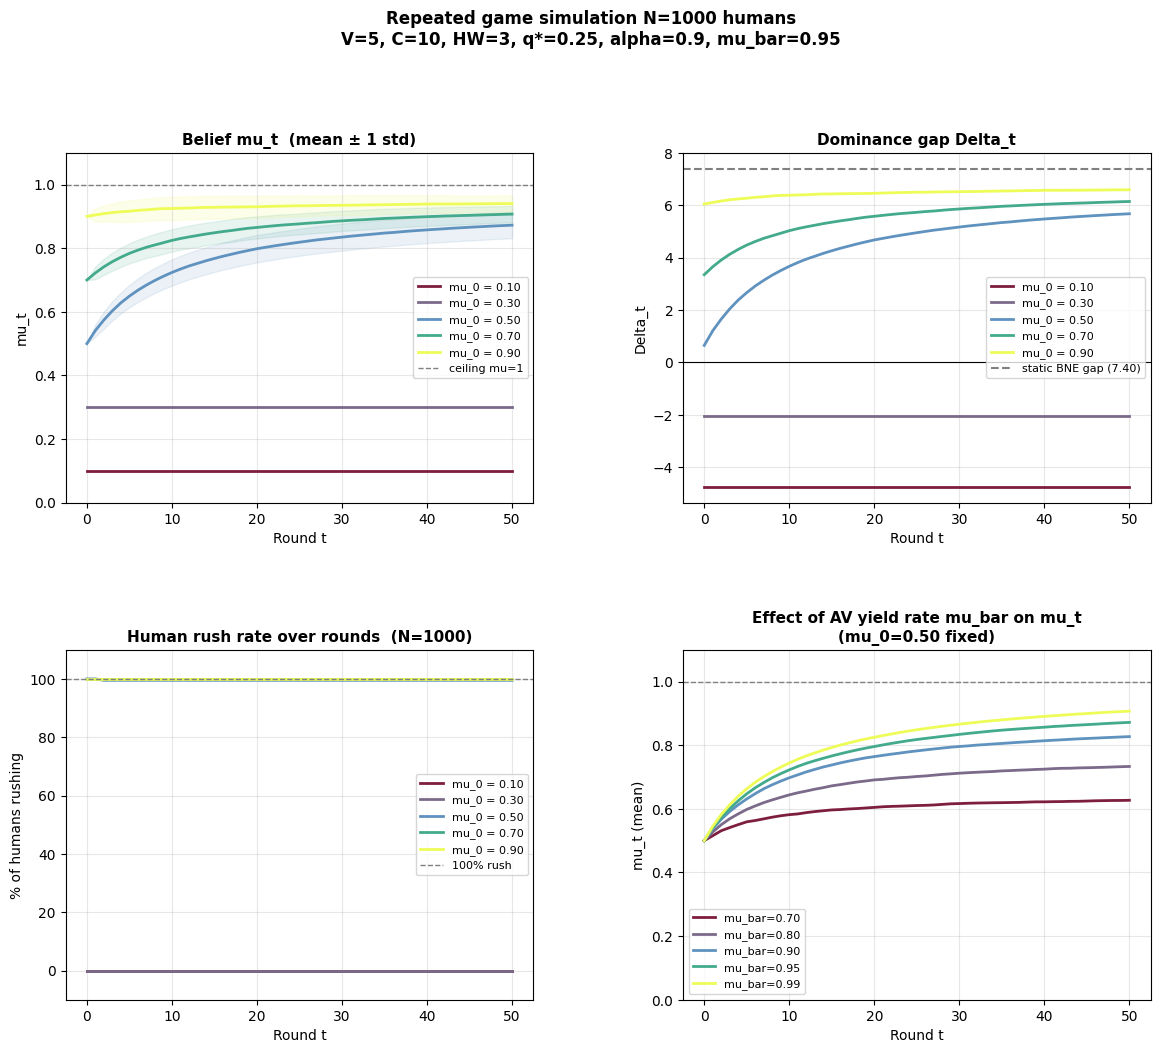

In [ ]:
fig = plt.figure(figsize=(14,11))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])

# Plot One: mu_t mean in 1 std
for i, (a0, b0, label) in enumerate(scenarios):
    mu_m = results[i]["mus_mean"]
    mu_s = results[i]["mus_std"]
    ax1.plot(rounds, mu_m, color=colors[i], linewidth=2, label=label)
    ax1.fill_between(rounds, mu_m - mu_s, mu_m + mu_s,
                     color=colors[i], alpha=0.12)
ax1.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="ceiling mu=1")
ax1.set_title("Belief mu_t  (mean ± 1 std)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Round t"); ax1.set_ylabel("mu_t")
ax1.set_ylim(0, 1.1); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# Plot 2: Dominance gap Delta_t
for i, (a0, b0, label) in enumerate(scenarios):
    ax2.plot(rounds, results[i]["deltas_mean"], color=colors[i],
             linewidth=2, label=label)
ax2.axhline(static, color="gray", linestyle="--", linewidth=1.5,
            label="static BNE gap ({:.2f})".format(static))
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Dominance gap Delta_t", fontsize=11, fontweight="bold")
ax2.set_xlabel("Round t"); ax2.set_ylabel("Delta_t")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# Plot 3: Rush rate over time
for i, (a0, b0, label) in enumerate(scenarios):
    ax3.plot(rounds, results[i]["rush_rate"] * 100,
             color=colors[i], linewidth=2, label=label)
ax3.axhline(100, color="gray", linestyle="--", linewidth=1, label="100% rush")
ax3.set_title("Human rush rate over rounds  (N={})".format(N_SIM),
              fontsize=11, fontweight="bold")
ax3.set_xlabel("Round t"); ax3.set_ylabel("% of humans rushing")
ax3.set_ylim(-10, 110); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# Plot 4: Effect of mu_bar on mu_t trajectory (mu_0 = 0.50 fixed)
mu_bars = [0.70, 0.80, 0.90, 0.95, 0.99]
for j, pb in enumerate(mu_bars):
    res = simulate_population(5, 5, pb, t, N_SIM)
    ax4.plot(rounds, res["mus_mean"], color=colors[j],
             linewidth=2, label="mu_bar={:.2f}".format(pb))
ax4.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax4.set_title("Effect of AV yield rate mu_bar on mu_t\n(mu_0=0.50 fixed)",
              fontsize=11, fontweight="bold")
ax4.set_xlabel("Round t"); ax4.set_ylabel("mu_t (mean)")
ax4.set_ylim(0, 1.1); ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

plt.suptitle(
    "Repeated game simulation N={} humans\n"
    "V={}, C={}, HW={}, q*={}, alpha={}, mu_bar={}".format(
        N_SIM, v, c, w, q_star, alpha, mu_bar),
    fontsize=12, fontweight="bold", y=1.01)

### Basic Findings
- After running some repeated games with 5 different starting beliefs with an assumed probability of AV yielding of 95%, what I've noticed is:
1. starting beliefs (0.10 and 0.30) NEVER update their belief.
2. starting beliefs (0.50, 0.70, 0.90) update their belief and begin to converge into the static gap we found previously.
3. mu_t values increase at varying intensity when the AV rushing/yielding probabilities are different.

Regarding (1), the reason why 0.10 and 0.30 never update their belief is because they never experience an AV yielding. They always yield.